In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import stim
import sinter
import matplotlib.pyplot as plt
import os
from qecsim.codes.surface_code_rotated.circuit import rotated_surface_code
from qecsim.tools.threshold_num.calc_threshold import threshold_approx
import pickle
import numpy as np
from matplotlib.ticker import FuncFormatter

In [3]:
task_noisy_long= [sinter.Task(
    circuit = rotated_surface_code(
        distance = d,
        rounds = d + 1, 
        logical_z = 0, 
        before_measurement_flip_prob = noise,
        before_round_depol_data = noise,
        after_clifford_depol = noise,
        after_reset_flip_prob = noise),
    json_metadata={'p': noise, 'distance' : d}
    ) 
    for noise in [0.001, 0.0015, 0.002, 0.0025, 0.005, 0.007, 0.0075, 0.008, 0.0085, 0.009, 0.0095, 0.01, 0.015, 0.1, 0.2, 0.3]
    for d in [3, 5, 7, 9, 11]
]

stats_noisy_long : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy_long,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=10000,
    print_progress=True
)

TypeError: rotated_surface_code() got an unexpected keyword argument 'logical_z'

In [ ]:
#Saving Stats with pickle
with open("rotated_full_noise_z_long.pkl", "wb") as file:
    pickle.dump(stats_noisy_long, file)

In [ ]:
#Loading Stats with pickle
with open("rotated_full_noise_z.pkl", "rb") as file:
    stats_noisy = pickle.load(file)


In [ ]:
# Reduce to only high distances
stats_noisy = [i for i in stats_noisy_long if i.json_metadata["distance"] in {9,11}]

In [ ]:
################
# Calc Threshold
################

# Create clean Data Points for approx
thr_list = [i for i in stats_noisy if i.json_metadata["p"] < 0.01]

# Approx thr
p_th = threshold_approx(thr_list)

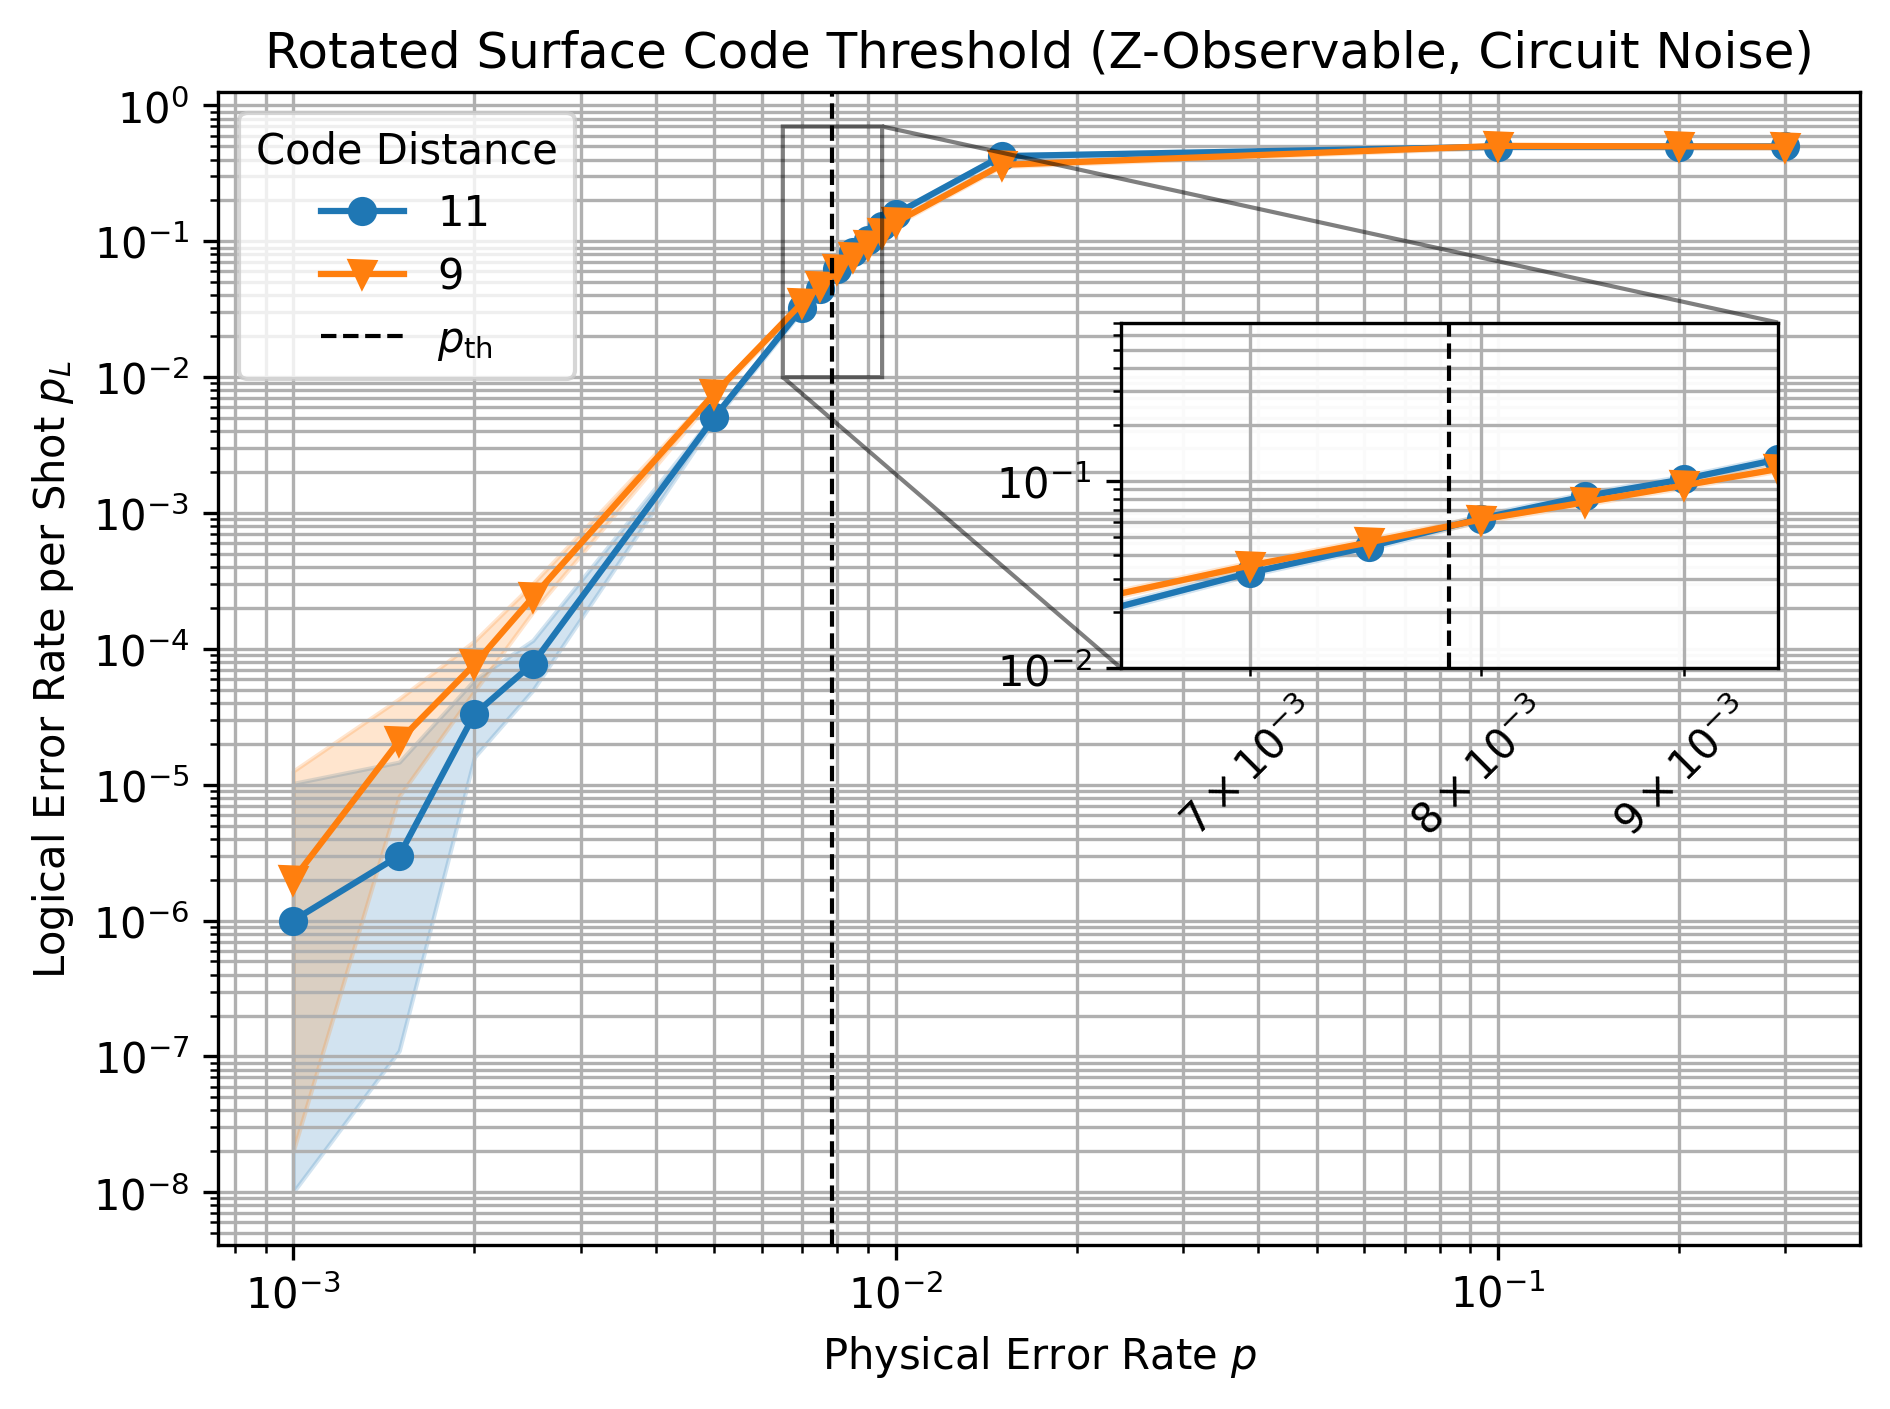

In [ ]:
###############################
# Plotting Noise (Z Observable)
###############################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax = ax,
    stats = stats_noisy,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])

# threshold line
ax.axvline(
    x = p_th,
    color="black",
    linestyle="--",
    linewidth=1,
    label=r"$p_{\mathrm{th}}$"
)
"""
ax.annotate(rf"$p_{{\mathrm{{th}}}} = {p_th:.2e}$",
            xy=(p_th, ax.get_ylim()[1]),
            xycoords='data',
            xytext=(-12, -100), textcoords='offset points',
            rotation=90, va='top', ha='left')
"""
ax.loglog()
ax.set_title("Rotated Surface Code Threshold (Z-Observable, Circuit Noise)")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $p_L$")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend(title="Code Distance")

############################################
# Plotting Zoomed in Section of the crossing
############################################

x1, x2, y1, y2 = 0.65e-2, 0.95e-2, 1e-2, 0.7
axins = ax.inset_axes([0.55, 0.5, 0.4, 0.30])

sinter.plot_error_rate(
    ax=axins,
    stats=stats_noisy,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['distance'])

# threshold line
axins.axvline(x=p_th, color="black", linestyle="--", linewidth=1)
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.loglog()

# Add grid and other atrributes
axins.grid(which='major')
axins.grid(which='minor')
axins.patch.set_facecolor("white")
axins.patch.set_alpha(0.95)

ax.indicate_inset_zoom(axins, edgecolor="black")

# Rotate X-labels
axins.tick_params(axis='x', which='both', rotation=45)
for lbl in axins.get_xticklabels():
    lbl.set_ha('right')  

# keep right‑alignment so the text ends exactly at the tick mark
for lbl in axins.get_xticklabels():
    lbl.set_ha('right') 

fig.set_dpi(300)
plt.tight_layout()
plt.show()

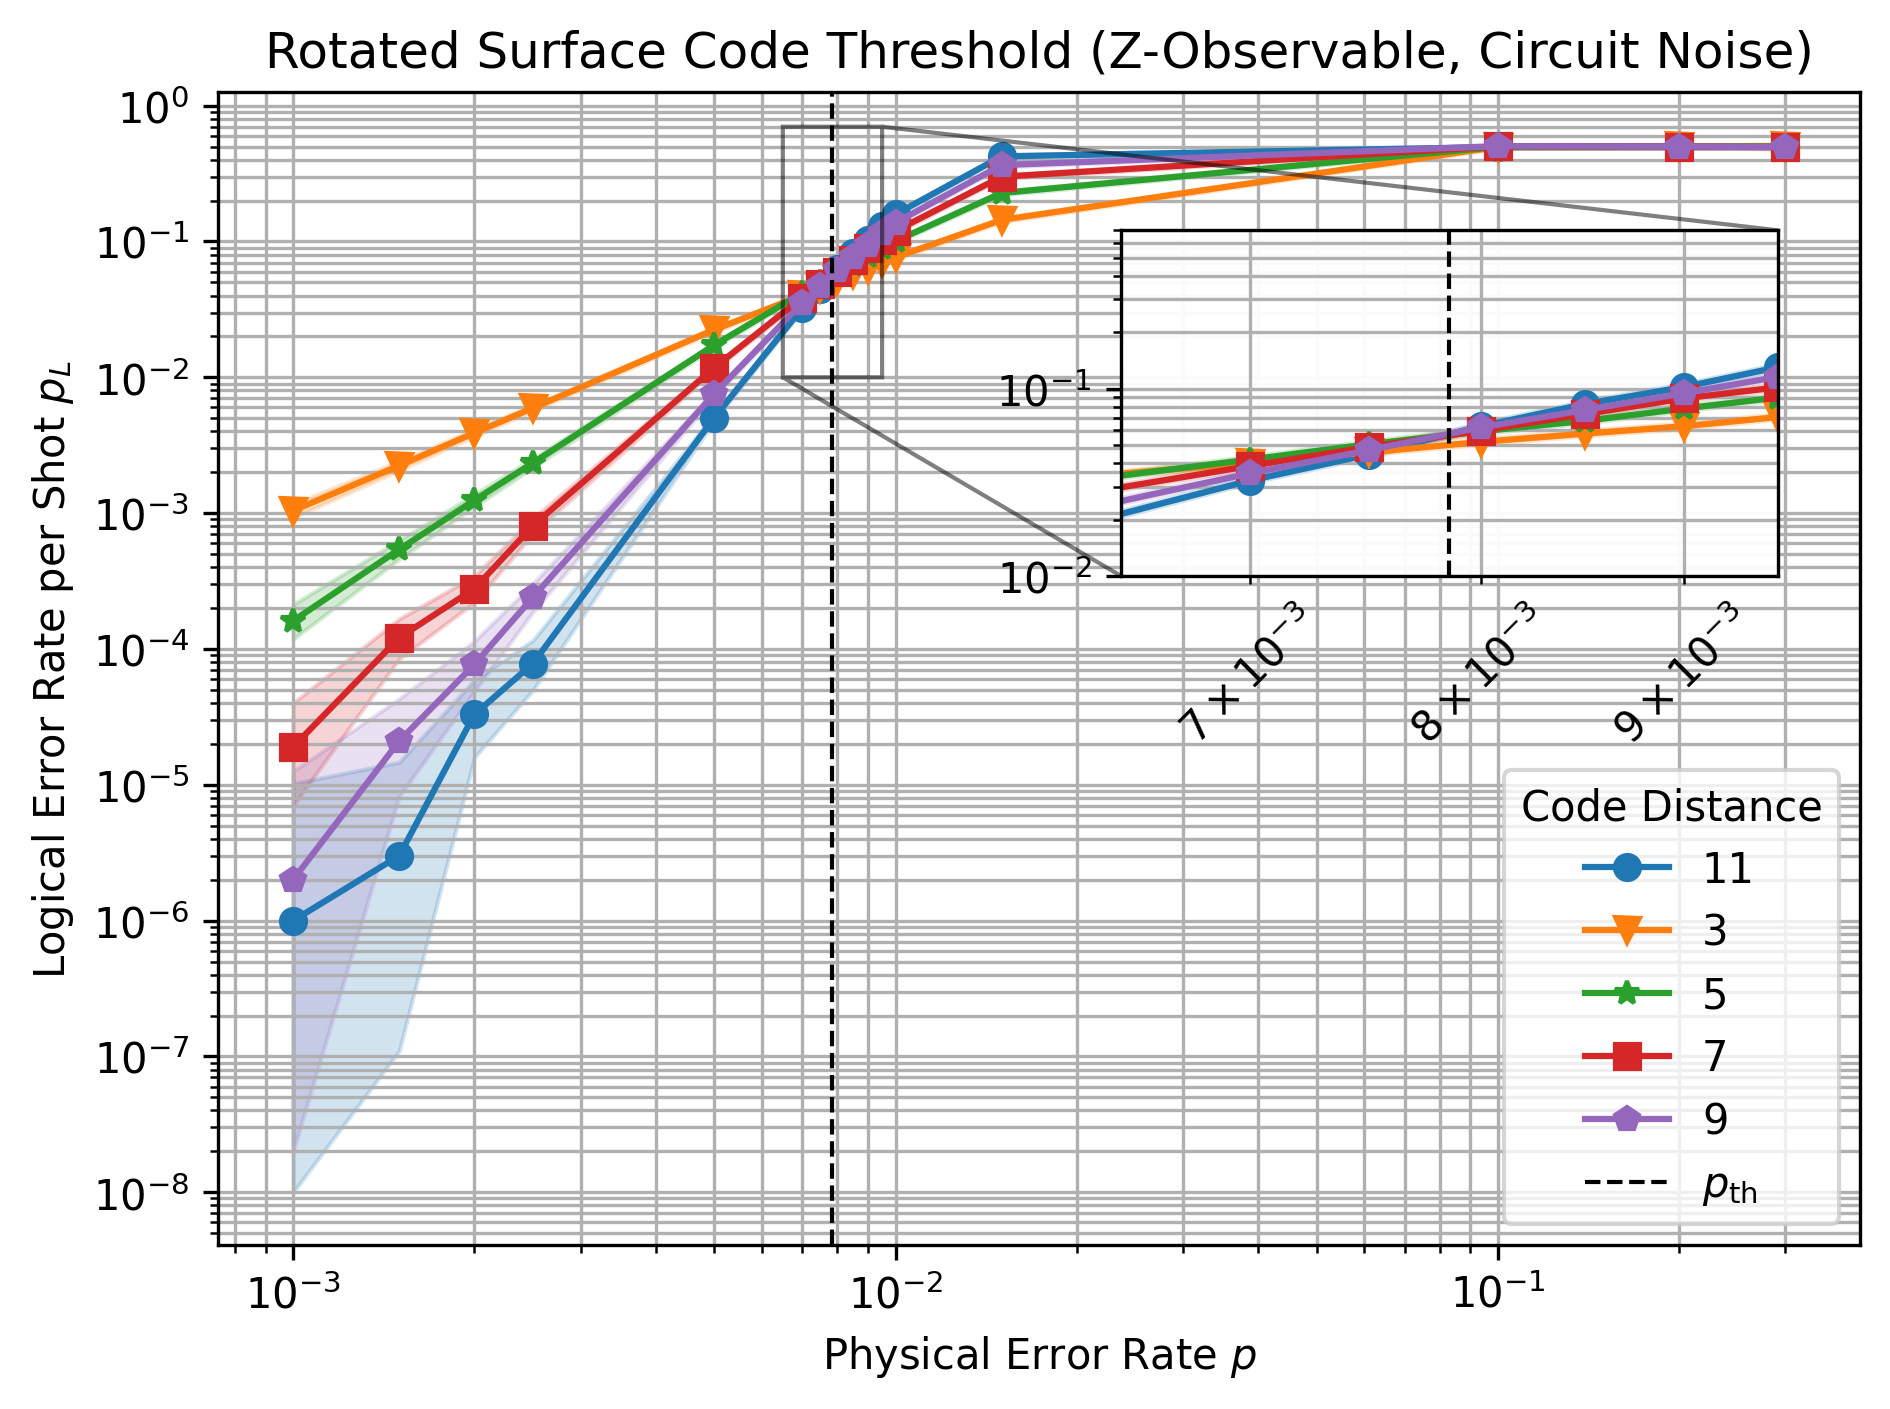

In [ ]:
###############################
# Plotting Noise (Z Observable)
###############################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax = ax,
    stats = stats_noisy_long,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])

# threshold line
ax.axvline(
    x = p_th,
    color="black",
    linestyle="--",
    linewidth=1,
    label=r"$p_{\mathrm{th}}$"
)

"""ax.annotate(rf"$p_{{\mathrm{{th}}}} = {p_th:.2e}$",
            xy=(p_th, ax.get_ylim()[1]),
            xycoords='data',
            xytext=(-12, -100), textcoords='offset points',
            rotation=90, va='top', ha='left')
"""

ax.loglog()
ax.set_title("Rotated Surface Code Threshold (Z-Observable, Circuit Noise)")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $p_L$")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend(title="Code Distance")

############################################
# Plotting Zoomed in Section of the crossing
############################################

x1, x2, y1, y2 = 0.65e-2, 0.95e-2, 1e-2, 0.7
axins = ax.inset_axes([0.55, 0.58, 0.4, 0.30])

sinter.plot_error_rate(
    ax=axins,
    stats=stats_noisy_long,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['distance'])

# threshold line
axins.axvline(x=p_th, color="black", linestyle="--", linewidth=1)
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.loglog()

# Add grid and other atrributes
axins.grid(which='major')
axins.grid(which='minor')
axins.patch.set_facecolor("white")
axins.patch.set_alpha(0.95)

ax.indicate_inset_zoom(axins, edgecolor="black")

# Rotate X-labels
axins.tick_params(axis='x', which='both', rotation=45)
for lbl in axins.get_xticklabels():
    lbl.set_ha('right')  

# keep right‑alignment so the text ends exactly at the tick mark
for lbl in axins.get_xticklabels():
    lbl.set_ha('right') 

fig.set_dpi(300)
plt.tight_layout()
plt.show()